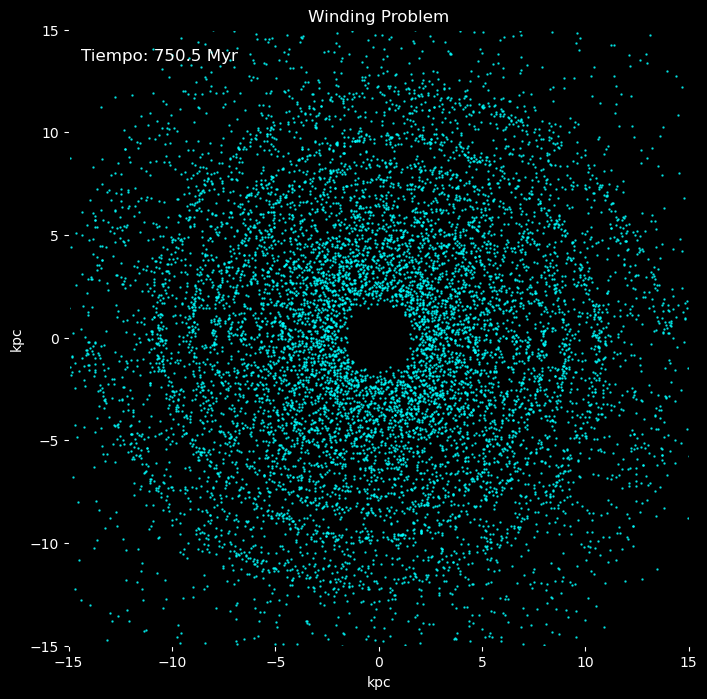

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Constantes físicas en unidades SI
kpc0 = 3.085677581e19        
Myr0 = 3.15576e13            
G0 = 6.67430e-11             
M_sol0 = 1.989e30 
M_gal0 = 1e11 * M_sol0 

# Reescalamiento
c = kpc0                  
M_gal = M_gal0              
T_scale = np.sqrt(c**3 / (G0 * M_gal)) 

kpc = kpc0 / c           # kpc será 1
M_gal = M_gal0 / M_gal   # M_gal será 1
G = 1.0
Myr = Myr0 / T_scale     # unidad de tiempo reescalada

# Configuración de la galaxia
num_brazos = 2    
N_por_brazo = 5000  
dt = 0.5 * Myr  
nsteps = 1500 

# Cálculo aceleración
def acceleration(pos):
    r2 = np.sum(pos**2, axis=1)
    r = np.sqrt(r2)
    a = -G * M_gal * pos / r[:, None]**3 
    return a

# CONDICIONES HÍBRIDAS: Geometría Lin-Shu + Cinemática Kepleriana
def make_hybrid_conditions(N_per_arm, m_arms):
    todas_posiciones = []

    # 1. GEOMETRÍA (Elipses de Lin-Shu)
    r = np.random.uniform(2.0, 14.0, N_per_arm) 
    e = 0.08 + 0.32 * np.random.rand(N_per_arm) 
    phi = 0.55 * (r / kpc) 
    nu = np.random.uniform(0, 2*np.pi, N_per_arm) 
    
    a = r / (1 - e**2) 
    rr = a * (1 - e**2) / (1 + e * np.cos(nu)) 
    
    x_orb = rr * np.cos(nu)
    y_orb = rr * np.sin(nu)
    
    c_ang = np.cos(phi)
    s_ang = np.sin(phi)
    x1 = c_ang * x_orb - s_ang * y_orb
    y1 = s_ang * x_orb + c_ang * y_orb
    pos1 = np.column_stack((x1, y1))

    for k in range(m_arms):
        theta = k * (2 * np.pi / m_arms)
        c_rot = np.cos(theta)
        s_rot = np.sin(theta)
        
        x_rot = c_rot * pos1[:, 0] - s_rot * pos1[:, 1]
        y_rot = s_rot * pos1[:, 0] + c_rot * pos1[:, 1]
        pos_k = np.column_stack((x_rot, y_rot))
        todas_posiciones.append(pos_k)

    # Matriz final de posiciones (Mantenemos la onda de densidad visualmente)
    pos_final = np.vstack(todas_posiciones)

    # 2. CINEMÁTICA "INCORRECTA" (Rotación Kepleriana circular)
    # Calculamos el radio real absoluto de cada estrella en su posición actual
    r_mag = np.sqrt(np.sum(pos_final**2, axis=1))
    
    # Imponemos velocidad circular v = sqrt(GM/r)
    v_mag = np.sqrt(G * M_gal / r_mag)
    
    # Calculamos componentes X e Y tangentes a la órbita circular (antihorario)
    vx_circ = -v_mag * (pos_final[:, 1] / r_mag)
    vy_circ =  v_mag * (pos_final[:, 0] / r_mag)
    vel_final = np.column_stack((vx_circ, vy_circ))

    return pos_final, vel_final

# Velocidad Verlet
def verlet_step(pos, vel):
    a = acceleration(pos)
    pos_new = pos + vel * dt + 0.5 * a * dt**2
    a_new = acceleration(pos_new)
    vel_new = vel + 0.5 * (a + a_new) * dt
    return pos_new, vel_new

# Inicialización
pos, vel = make_hybrid_conditions(N_por_brazo, num_brazos)

# Construimos la figura
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor("black")
fig.patch.set_facecolor("black")

scatter = ax.scatter(
    pos[:, 0] / kpc,
    pos[:, 1] / kpc,
    s=0.5,
    color='cyan',
    alpha=0.8
)

ax.set_xlim(-15, 15) 
ax.set_ylim(-15, 15)
ax.set_xlabel("kpc", color="white")
ax.set_ylabel("kpc", color="white")
ax.tick_params(colors="white")
ax.set_title("Winding Problem", color="white")

time_text = ax.text(
    0.02, 0.95, "",
    transform=ax.transAxes,
    color="white", fontsize=12
)

# Animación
t = 0.0

def update(frame):
    global pos, vel, t
    pasos_por_frame = 1

    for _ in range(pasos_por_frame):
        pos, vel = verlet_step(pos, vel)
        t += dt

    scatter.set_offsets(pos / kpc)
    time_text.set_text(f"Tiempo: {t/Myr:.1f} Myr")
    return scatter, time_text

ani = FuncAnimation(
    fig,
    update,
    frames=nsteps,
    interval=25,
    blit=False
)
ani.save("hibrido_winding_problem.gif", writer='pillow', fps=30)
plt.show()

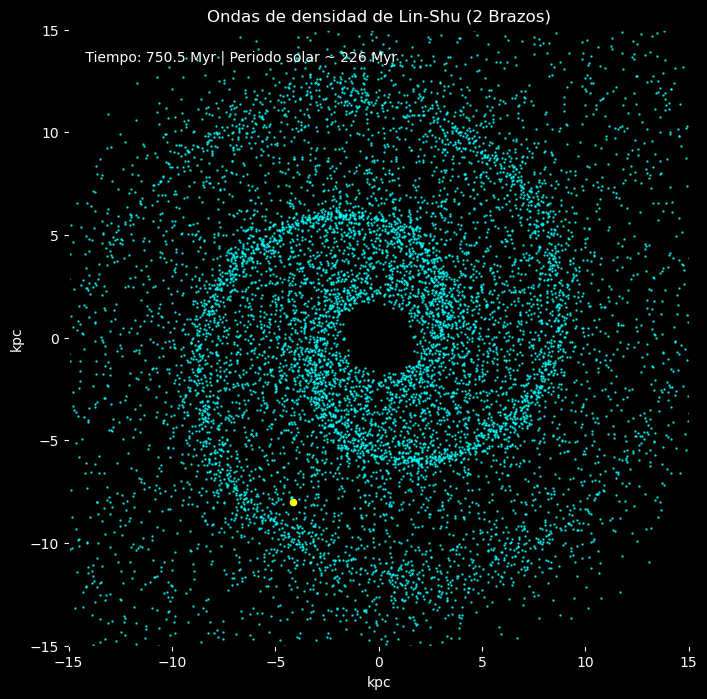

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


kpc0 = 3.085677581e19        
Myr0 = 3.15576e13            
G0 = 6.67430e-11             
M_sol0 = 1.989e30 # Masa solar (kg)
M_gal0 = 1e11 * M_sol0 #masa de bariónica de la galaxia (kg)

#reescalamiento
c = kpc0                  
M_gal = M_gal0              
T_scale = np.sqrt(c**3 / (G0 * M_gal)) #tiempo reescalado para que G=1

kpc = kpc0 / c           #kpc será 1
M_gal = M_gal0 / M_gal   #M_gal será 1
G = 1.0
Myr = Myr0 / T_scale     #unidad de tiempo reescalda
#Configuración de la galaxia y simulación
num_brazos = 2     #2 brazos como la Vía Láctea
N_por_brazo = 5000  #número idóneo de estrellas para animación fluida y que no tarde mucho
dt = 0.5 * Myr  
nsteps = 1500 #duración de la simulación

#calculo aceleración de 
def acceleration(pos):
    r2 = np.sum(pos**2, axis=1)
    r = np.sqrt(r2)
    a = -G * M_gal * pos / r[:, None]**3 #fuerzo que sea una columna para la división
    return a
#condiciones iniciales para órbitas tipo Lin-Shu (elipses)
def make_initial_conditions(N_per_arm, m_arms):
    # Generamos las condiciones para un brazo base
    r = np.random.uniform(2.0, 14.0, N_per_arm) #distancias entre 2 y 14 kpc
    e = 0.08 + 0.32 * np.random.rand(N_per_arm) #excentricidad aleatoria entre 0.08 y 0.4
    phi = 0.55 * (r / kpc) #orientación correlacionada con el tamaño para crear la espiral
    nu = np.random.uniform(0, 2*np.pi, N_per_arm) #anomalía
    
    a = r / (1 - e**2) #calcula el semieje mayor
    rr = a * (1 - e**2) / (1 + e * np.cos(nu)) #radio orbital a partir de la ecuación de la cónica
    #pasamos a cartesianas
    x_orb = rr * np.cos(nu)
    y_orb = rr * np.sin(nu)
    #aplica la matriz de rotación para orientar las elipses según phi
    c = np.cos(phi)
    s = np.sin(phi)
    x1 = c * x_orb - s * y_orb
    y1 = s * x_orb + c * y_orb
    pos1 = np.column_stack((x1, y1))

    #velocidad del brazo base
    p = a * (1 - e**2) 
    h = np.sqrt(G * M_gal * p) #momento angular específico
    
    vx_orb = -(G * M_gal  / h) * np.sin(nu) #velocidad tangencial 
    vy_orb = (G * M_gal  / h) * (e + np.cos(nu)) #velocidad radial
    #aplicamos rotación a las velocidades
    vx1 = c * vx_orb - s * vy_orb
    vy1 = s * vx_orb + c * vy_orb
    vel1 = np.column_stack((vx1, vy1))

    #ahora para más brazos, rotamos las posiciones y velocidades del brazo base
    todas_posiciones = []
    todas_velocidades = []

    for k in range(m_arms):
        # Ángulo de rotación para este brazo (fracciones de 360 grados)
        theta = k * (2 * np.pi / m_arms)
        
        c_rot = np.cos(theta)
        s_rot = np.sin(theta)
        
        #rotamos las posiciones usando la misma matriz de rotación
        x_rot = c_rot * pos1[:, 0] - s_rot * pos1[:, 1]
        y_rot = s_rot * pos1[:, 0] + c_rot * pos1[:, 1]
        pos_k = np.column_stack((x_rot, y_rot))
        
        #rotamos las velocidades
        vx_rot = c_rot * vel1[:, 0] - s_rot * vel1[:, 1]
        vy_rot = s_rot * vel1[:, 0] + c_rot * vel1[:, 1]
        vel_k = np.column_stack((vx_rot, vy_rot))
        
        todas_posiciones.append(pos_k)
        todas_velocidades.append(vel_k)

    #combinamos en un array final
    pos_final = np.vstack(todas_posiciones)
    vel_final = np.vstack(todas_velocidades)

    return pos_final, vel_final

#velocidad verlet
def verlet_step(pos, vel):
    a = acceleration(pos)
    pos_new = pos + vel * dt + 0.5 * a * dt**2
    
    a_new = acceleration(pos_new)
    vel_new = vel + 0.5 * (a + a_new) * dt
    
    return pos_new, vel_new

#llamamos a la función para obtener las condiciones iniciales
pos, vel = make_initial_conditions(N_por_brazo, num_brazos)
#buscamos la estrella más cercana a la posición del Sol en la Vía Láctea
R_sun = 7.9 * kpc
idx_sun = np.argmin(np.abs(np.sqrt(np.sum(pos**2, axis=1)) - R_sun))
#calculamos el ángulo del Sol para luego detectar su periodo
sun_angle0 = np.arctan2(pos[idx_sun,1], pos[idx_sun,0])
sun_period = None
sun_crossings = []

#construimos la figura
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor("black")
fig.patch.set_facecolor("black")

scatter = ax.scatter(
    pos[:, 0] / kpc,
    pos[:, 1] / kpc,
    s=0.5,
    color='cyan',
    alpha=0.8
)
#marcamos la posición del Sol
sun_dot = ax.scatter(
    pos[idx_sun, 0] / kpc,
    pos[idx_sun, 1] / kpc,
    s=20,
    color='yellow'
)

ax.set_xlim(-15, 15) 
ax.set_ylim(-15, 15)
ax.set_xlabel("kpc", color="white")
ax.set_ylabel("kpc", color="white")
ax.tick_params(colors="white")
ax.set_title(f"Ondas de densidad de Lin-Shu ({num_brazos} Brazos)", color="white")

time_text = ax.text(
    0.02, 0.95, "",
    transform=ax.transAxes,
    color="white"
)

#animación
t = 0.0

def update(frame):
    global pos, vel, t, sun_period

    pasos_por_frame = 1

    for _ in range(pasos_por_frame):
        angle_old = np.arctan2(pos[idx_sun, 1], pos[idx_sun, 0])
        
        pos, vel = verlet_step(pos, vel)
        t += dt
        
        angle_new = np.arctan2(pos[idx_sun, 1], pos[idx_sun, 0])
        #detectamos si el Sol cruza su ángulo inicial para medir su periodo
        if sun_period is None:
            if angle_old <= sun_angle0 and angle_new > sun_angle0:
                sun_crossings.append(t)
                if len(sun_crossings) == 2:
                    sun_period = (sun_crossings[1] - sun_crossings[0]) / Myr

    scatter.set_offsets(pos / kpc)
    sun_dot.set_offsets(pos[idx_sun] / kpc)
    if sun_period is None:
        txt = f"t = {t/Myr:.1f} Myr | Buscando periodo..."
    else:
        txt = f" Tiempo: {t/Myr:.1f} Myr | Periodo solar ~ {sun_period:,.0f} Myr"

    time_text.set_text(txt)
    return scatter, sun_dot, time_text

ani = FuncAnimation(
    fig,
    update,
    frames=nsteps,
    interval=25,
    blit=False
)
ani.save("galaxialinshu.gif", writer='pillow', fps=30)
plt.show()

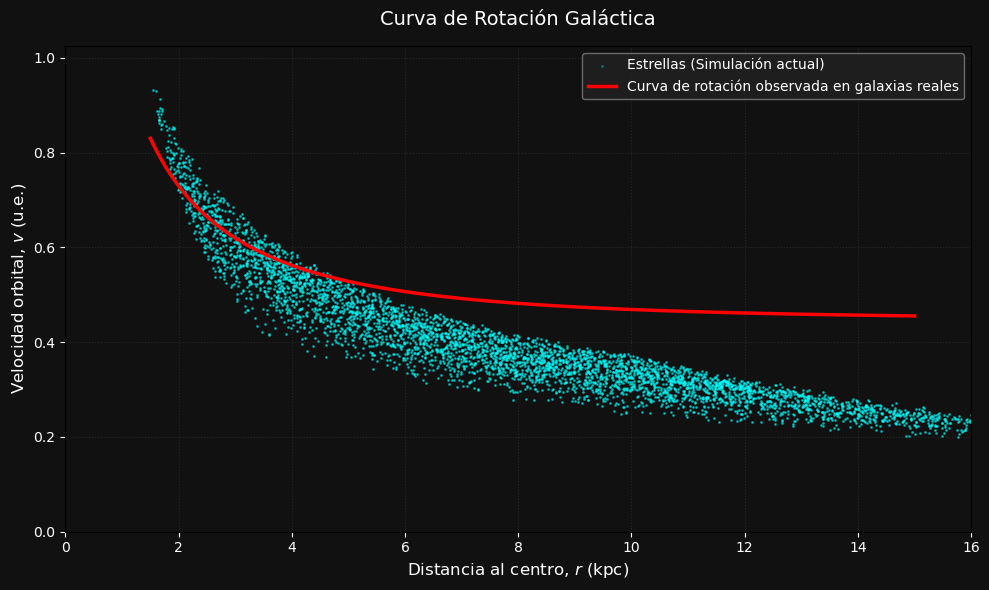

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Constantes y factores de reescalamiento originales
kpc0 = 3.085677581e19        
G0 = 6.67430e-11             
M_sol0 = 1.989e30 
M_gal0 = 1e11 * M_sol0 

c = kpc0                  
M_gal_scaled = M_gal0 / M_gal0  
G = 1.0
kpc = kpc0 / c                  

# Parámetros estelares
N_por_brazo = 5000
num_brazos = 2

# condiciones iniciales Lin-Shu
def make_initial_conditions(N_per_arm, m_arms):
    r = np.random.uniform(2.0, 14.0, N_per_arm) 
    e = 0.08 + 0.32 * np.random.rand(N_per_arm) 
    phi = 0.55 * (r / kpc) 
    nu = np.random.uniform(0, 2*np.pi, N_per_arm) 
    
    a = r / (1 - e**2) 
    rr = a * (1 - e**2) / (1 + e * np.cos(nu)) 
    
    x_orb = rr * np.cos(nu)
    y_orb = rr * np.sin(nu)
    
    c_rot = np.cos(phi)
    s_rot = np.sin(phi)
    x1 = c_rot * x_orb - s_rot * y_orb
    y1 = s_rot * x_orb + c_rot * y_orb
    pos1 = np.column_stack((x1, y1))

    p = a * (1 - e**2) 
    h = np.sqrt(G * M_gal_scaled * p) 
    
    vx_orb = -(G * M_gal_scaled / h) * np.sin(nu) 
    vy_orb = (G * M_gal_scaled / h) * (e + np.cos(nu)) 
    
    vx1 = c_rot * vx_orb - s_rot * vy_orb
    vy1 = s_rot * vx_orb + c_rot * vy_orb
    vel1 = np.column_stack((vx1, vy1))

    todas_posiciones = []
    todas_velocidades = []

    for k in range(m_arms):
        theta = k * (2 * np.pi / m_arms)
        c_rot_k = np.cos(theta)
        s_rot_k = np.sin(theta)
        
        x_rot = c_rot_k * pos1[:, 0] - s_rot_k * pos1[:, 1]
        y_rot = s_rot_k * pos1[:, 0] + c_rot_k * pos1[:, 1]
        
        vx_rot = c_rot_k * vel1[:, 0] - s_rot_k * vel1[:, 1]
        vy_rot = s_rot_k * vel1[:, 0] + c_rot_k * vel1[:, 1]
        
        todas_posiciones.append(np.column_stack((x_rot, y_rot)))
        todas_velocidades.append(np.column_stack((vx_rot, vy_rot)))

    return np.vstack(todas_posiciones), np.vstack(todas_velocidades)

#generamos datos reales
pos, vel = make_initial_conditions(N_por_brazo, num_brazos)
radios = np.sqrt(pos[:, 0]**2 + pos[:, 1]**2) / kpc
velocidades = np.sqrt(vel[:, 0]**2 + vel[:, 1]**2)
#curva
r_teorico = np.linspace(1.5, 15.0, 500)


v_kepleriana = np.sqrt(G * M_gal_scaled / r_teorico)
#cogemos valores tabulados del halo de materia oscura para ajustar la curva
v_halo_max = 0.45  # Velocidad asintótica del halo
r_core = 3.0       # Radio del núcleo del halo
v_materia_oscura = v_halo_max * (r_teorico / (r_teorico + r_core))

v_total_con_mo = np.sqrt(v_kepleriana**2 + v_materia_oscura**2)

#grafica comparativa
plt.figure(figsize=(10, 6), facecolor='#111111')
ax = plt.gca()
ax.set_facecolor('#111111')

#  Nube de puntos de estrellas actuales (Keplerianas)
ax.scatter(radios, velocidades, s=1, color='cyan', alpha=0.3, label='Estrellas (Simulación actual)')


#  Línea teórica Total Plana (Lo que se observa en galaxias reales como la Vía Láctea)
ax.plot(r_teorico, v_total_con_mo, color='red', linestyle='-', linewidth=2.5, 
        label='Curva de rotación observada en galaxias reales')

ax.set_title("Curva de Rotación Galáctica", color='white', fontsize=14, pad=15)
ax.set_xlabel("Distancia al centro, $r$ (kpc)", color='white', fontsize=12)
ax.set_ylabel("Velocidad orbital, $v$ (u.e.)", color='white', fontsize=12)

ax.tick_params(colors='white', labelsize=10)
ax.grid(True, color='gray', linestyle=':', alpha=0.2)
ax.set_xlim(0, 16)
ax.set_ylim(0, np.max(velocidades) * 1.1)

legend = ax.legend(loc='upper right', facecolor='#222222', edgecolor='gray', fontsize=10)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.savefig("curva_rotacion_materia_oscura.png", dpi=300, facecolor='#111111')
plt.show()

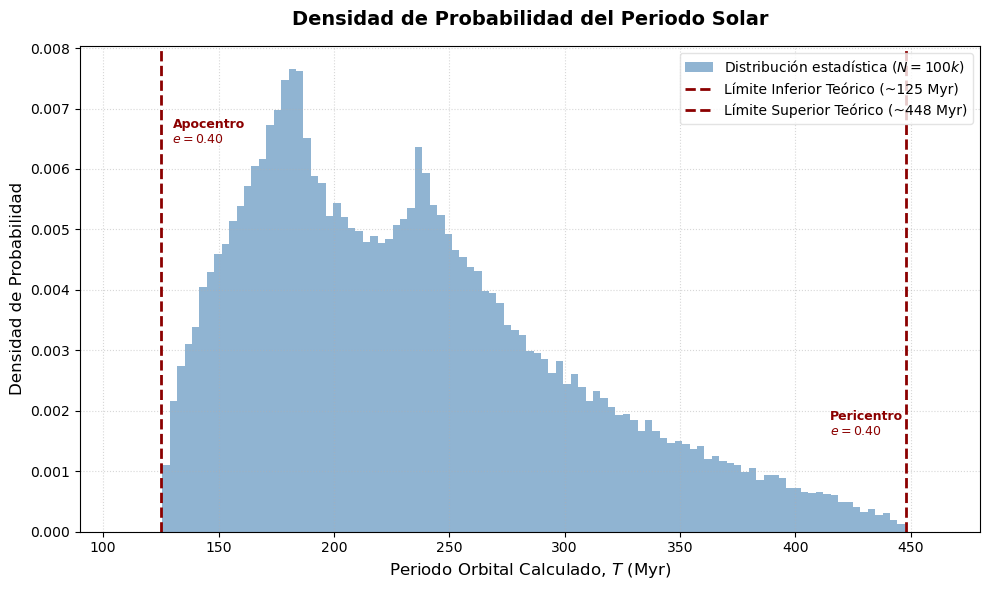

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# constantes y factores de reescalamiento originales
kpc0 = 3.085677581e19        
Myr0 = 3.15576e13            
G0 = 6.67430e-11             
M_sol0 = 1.989e30 
M_gal0 = 1e11 * M_sol0 

c = kpc0                  
M_gal = M_gal0              
T_scale = np.sqrt(c**3 / (G0 * M_gal)) 

kpc = kpc0 / c           
M_gal_scaled = M_gal0 / M_gal  
G = 1.0
Myr = Myr0 / T_scale    

R_sun = 7.9 * kpc  # Distancia fija a la que busco el Sol

#simulo 100k soles para obtener una distribución estadística de sus periodos
N_muestras = 100000

# Generamos distribuciones independientes idénticas a las de tu función make_initial_conditions
e_sim = 0.08 + 0.32 * np.random.rand(N_muestras)   # Excentricidad entre 0.08 y 0.40
nu_sim = np.random.uniform(0, 2 * np.pi, N_muestras) # Anomalía verdadera entre 0 y 2pi

# Aplicamos las ecuaciones dinámicas invertidas de mi código para hallar el periodo real:
#Calculamos el semieje mayor 'a' que tendría una estrella para estar HOY a R_sun
# Como R_sun = a * (1 - e^2) / (1 + e * cos(nu)), despejamos 'a':
a_sim = R_sun * (1 + e_sim * np.cos(nu_sim)) / (1 - e_sim**2)

# Por la tercera ley de Kepler, el periodo orbital es T = 2 * pi * sqrt(a^3 / (G * M))
periodos_inerciales = 2 * np.pi * np.sqrt(a_sim**3 / (G * M_gal_scaled))
periodos_myr = periodos_inerciales / Myr  # Convertimos a millones de años

#graficamos
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()

# Dibujamos el histograma de densidad de probabilidad (normalizado)
count, bins, patches = ax.hist(
    periodos_myr, bins=100, density=True, alpha=0.6, 
    color='steelblue', edgecolor='none', label='Distribución estadística ($N=100k$)'
)




# Líneas de los límites teóricos
ax.axvline(125, color='darkred', linestyle='--', linewidth=2, label='Límite Inferior Teórico (~125 Myr)')
ax.axvline(448, color='darkred', linestyle='--', linewidth=2, label='Límite Superior Teórico (~448 Myr)')
ax.text(130, ax.get_ylim()[1]*0.8, 'Apocentro\n$e=0.40$', color='darkred', fontsize=9, fontweight='bold')
ax.text(415, ax.get_ylim()[1]*0.2, 'Pericentro\n$e=0.40$', color='darkred', fontsize=9, fontweight='bold')



ax.set_title("Densidad de Probabilidad del Periodo Solar", fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel("Periodo Orbital Calculado, $T$ (Myr)", fontsize=12)
ax.set_ylabel("Densidad de Probabilidad", fontsize=12)

ax.set_xlim(90, 480)
ax.grid(True, linestyle=':', alpha=0.5)

ax.legend(loc='upper right', fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro')

plt.tight_layout()
plt.savefig("distribucion_periodo_sol.png", dpi=300)
plt.show()